In [8]:
import os, sys
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))  # ensure project root
sys.path.insert(0, os.getcwd())
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

import pypsa
import yaml
import pandas as pd

from src import model

In [9]:
networks = {"Existing model": pypsa.Network("models_with_existing/base_case.nc"),
            "Optimized existing model": pypsa.Network("models_with_existing_optimized/base_case.nc")}

c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  attrs.loc[bool_b, "default"] = attrs.loc[bool_b].isin({True, "True"})
c:\Miniconda3\envs\pypsa-longyearbyen\Lib\site-packages\pypsa\components.py:323: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64,

In [10]:
networks["Optimized existing model"].links

,bus0,bus1,carrier,efficiency,p_nom,p_nom_extendable,capital_cost,p_nom_opt,bus2,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
GenSet,diesel bus,AC bus,diesel,0.40,0.0,True,0.000000,263.450420,heat bus,0.20,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
charge,AC bus,battery bus,AC,0.98,0.0,True,0.000000,17162.583689,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
discharge,battery bus,AC bus,AC,1.00,0.0,True,0.000000,17162.978049,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
electrolysis,AC bus,hydrogen bus,hydrogen,0.60,0.0,True,155.867958,0.000000,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
fuel cell,hydrogen bus,AC bus,hydrogen,0.60,0.0,True,270.518081,0.000000,heat bus,0.32,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Boiler,AC bus,heat bus,AC,0.90,0.0,True,9.218456,0.000000,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Geothermal heat pump,AC bus,heat bus,AC,4.00,0.0,True,307.946734,7.099047,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Boiler - existing,AC bus,heat bus,AC,0.90,128.0,False,9.218456,128.000000,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [11]:
def get_costs(n):
    stores_costs=n.stores["e_nom_opt"] * n.stores["capital_cost"]
    storage_units_costs=n.storage_units["p_nom_opt"] * n.storage_units["capital_cost"]
    gen_costs = n.generators["p_nom_opt"] * n.generators["capital_cost"]
    link_costs = n.links["p_nom_opt"] * n.links["capital_cost"]
    print(link_costs)
    costs= pd.concat([stores_costs,storage_units_costs,gen_costs,link_costs],axis=0)
    costs["diesel_marginal"]=n.generators_t.p.sum().loc["Diesel_import"]*n.generators["marginal_cost"].loc["Diesel_import"]+n.generators_t.p.sum().loc["Diesel_import-existing"]*n.generators["marginal_cost"].loc["Diesel_import-existing"]
    #costs["Wind"] = gen_costs.iloc[:15].sum()
    # costs = costs.loc[costs > 10]
    # print(costs)
    exchange_rate=0.01192

    simple_costs = pd.Series({'Wind': (costs['SWP turbine']+costs["IceWind turbine"])*exchange_rate,
                              'PV': (costs['PV park']+costs['PV roof']+costs["PV roof - existing"]+costs["PV park - existing"])*exchange_rate,
                              'Hydrogen': (costs['fuel cell'] + costs['electrolysis'] + costs['fuel cell']+costs["hydrogen storage"])*exchange_rate,
                              'Hot water storage':(costs['hot water storage']+costs["hot water storage - existing"])*exchange_rate,
                              'Diesel':(costs['Diesel_import']+costs['diesel_marginal']+costs["Diesel_import-existing"])*exchange_rate,
                              'Boiler':(costs['Boiler']+costs["Boiler - existing"])*exchange_rate,
                              'Batteries': (costs['batteries']+costs["batteries-existing"])*exchange_rate,
                              "Geothermal":(costs["Geothermal heat pump"]*exchange_rate)})
    simple_costs = pd.DataFrame(simple_costs / 1e3, columns=[""]).transpose()
    print(simple_costs)
    return simple_costs

In [12]:
costs_dict = {name: get_costs(n) for name, n in networks.items()}
costs = pd.concat((costs_dict.values()))
costs.index = (costs_dict.keys())

Link
GenSet                     0.000000
charge                     0.000000
discharge                  0.000000
electrolysis               0.000000
fuel cell                  0.000000
Boiler                     0.000000
Geothermal heat pump       0.000000
Boiler - existing       1179.962329
dtype: float64
  Wind        PV  Hydrogen  Hot water storage    Diesel    Boiler  Batteries  \
   0.0  1.139005       0.0           0.081721  1.159269  0.014065   0.777633   

  Geothermal  
         0.0  
Link
GenSet                     0.000000
charge                     0.000000
discharge                  0.000000
electrolysis               0.000000
fuel cell                  0.000000
Boiler                     0.000000
Geothermal heat pump    2186.128459
Boiler - existing       1179.962329
dtype: float64
     Wind        PV  Hydrogen  Hot water storage    Diesel    Boiler  \
  0.32115  1.139005       0.0           0.081721  0.523773  0.014065   

  Batteries  Geothermal  
   0.777633    0.02605

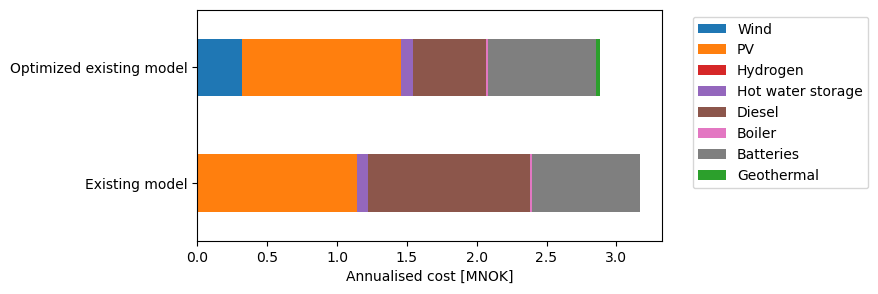

In [13]:
color_dict = {
    'Wind': '#1f77b4',  # Blue
    'PV': '#ff7f0e',  # Orange
    'Geothermal': '#2ca02c',  # Green
    'Hydrogen': '#d62728',  # Red
    'Hot water storage': '#9467bd',  # Purple
    'Diesel': '#8c564b',   # Brown
    'Boiler': '#e377c2',  # Pink
    'Batteries':'#7f7f7f'   # Grey
}
ax = costs.plot.barh(stacked=True, figsize=(6, 3),color=color_dict)
handles, labels = ax.get_legend_handles_labels()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("Annualised cost [MNOK]")
plt.savefig("figures/cost_comparison.pdf", bbox_inches='tight')